In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 재현성
torch.manual_seed(0)

# 파수
k = 4.0

# PINN 모델
class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 40),
            nn.Tanh(),
            nn.Linear(40, 1)
        )

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        return self.net(inp)

model = PINN2D()

# 내부 collocation points
N_f = 2000
x_f = torch.rand((N_f, 1), requires_grad=True)
y_f = torch.rand((N_f, 1), requires_grad=True)

# 경계 points
N_b = 400

# 아래/위 경계 (y=0, y=1)
x_b1 = torch.rand((N_b, 1), requires_grad=True)
y_b1 = torch.zeros((N_b, 1), requires_grad=True)

x_b2 = torch.rand((N_b, 1), requires_grad=True)
y_b2 = torch.ones((N_b, 1), requires_grad=True)

# 왼쪽/오른쪽 경계 (x=0, x=1)
x_b3 = torch.zeros((N_b, 1), requires_grad=True)
y_b3 = torch.rand((N_b, 1), requires_grad=True)

x_b4 = torch.ones((N_b, 1), requires_grad=True)
y_b4 = torch.rand((N_b, 1), requires_grad=True)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# 학습
for epoch in range(3000):
    u_f = model(x_f, y_f)

    # 1차 미분
    u_x = torch.autograd.grad(
        u_f, x_f, torch.ones_like(u_f), create_graph=True
    )[0]
    u_y = torch.autograd.grad(
        u_f, y_f, torch.ones_like(u_f), create_graph=True
    )[0]

    # 2차 미분
    u_xx = torch.autograd.grad(
        u_x, x_f, torch.ones_like(u_x), create_graph=True
    )[0]
    u_yy = torch.autograd.grad(
        u_y, y_f, torch.ones_like(u_y), create_graph=True
    )[0]

    # 소스항 f(x,y)
    f_xy = (-2 * np.pi**2 + k**2) * torch.sin(np.pi * x_f) * torch.sin(np.pi * y_f)

    # PDE loss
    loss_pde = torch.mean((u_xx + u_yy + k**2 * u_f - f_xy) ** 2)

    # 경계 loss (u=0)
    u_b1 = model(x_b1, y_b1)
    u_b2 = model(x_b2, y_b2)
    u_b3 = model(x_b3, y_b3)
    u_b4 = model(x_b4, y_b4)

    loss_bc = (
        torch.mean(u_b1**2) +
        torch.mean(u_b2**2) +
        torch.mean(u_b3**2) +
        torch.mean(u_b4**2)
    )

    loss = loss_pde + 10.0 * loss_bc

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 300 == 0:
        print(
            f"epoch={epoch}, total={loss.item():.6e}, "
            f"pde={loss_pde.item():.6e}, bc={loss_bc.item():.6e}"
        )

epoch=0, total=2.316504e+00, pde=2.257275e+00, bc=5.922979e-03
epoch=300, total=2.096817e+00, pde=2.021864e+00, bc=7.495314e-03
epoch=600, total=8.530650e-01, pde=2.701474e-01, bc=5.829176e-02
epoch=900, total=7.235099e-01, pde=1.913148e-01, bc=5.321951e-02
epoch=1200, total=3.690149e-01, pde=6.156325e-02, bc=3.074517e-02
epoch=1500, total=1.122994e-01, pde=3.808576e-02, bc=7.421361e-03
epoch=1800, total=5.578643e-02, pde=2.785744e-02, bc=2.792899e-03
epoch=2100, total=3.316732e-02, pde=1.863994e-02, bc=1.452739e-03
epoch=2400, total=4.337428e-01, pde=4.037997e-01, bc=2.994306e-03
epoch=2700, total=9.484013e-03, pde=7.285181e-03, bc=2.198832e-04


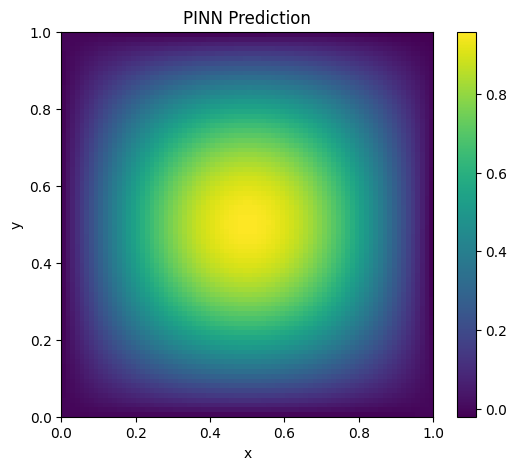

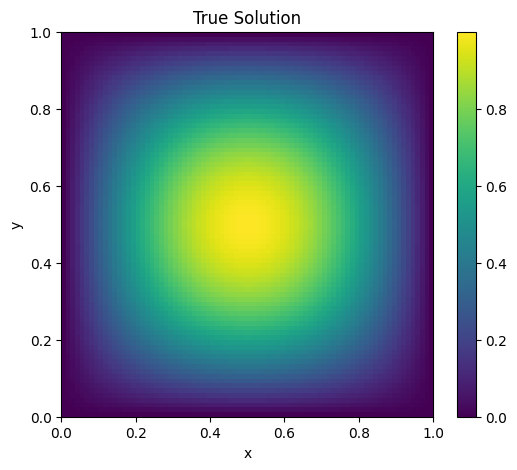

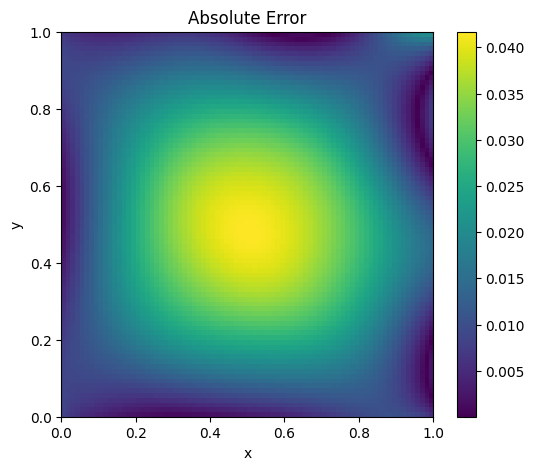

Mean absolute error = 0.019760748867919162
Max absolute error  = 0.0416860105350918


In [2]:
# 테스트 그리드
n_plot = 80
xv = np.linspace(0, 1, n_plot)
yv = np.linspace(0, 1, n_plot)
X, Y = np.meshgrid(xv, yv)

x_test = torch.tensor(X.reshape(-1, 1), dtype=torch.float32)
y_test = torch.tensor(Y.reshape(-1, 1), dtype=torch.float32)

with torch.no_grad():
    U_pred = model(x_test, y_test).cpu().numpy().reshape(n_plot, n_plot)

U_true = np.sin(np.pi * X) * np.sin(np.pi * Y)
U_err = np.abs(U_pred - U_true)

plt.figure(figsize=(6, 5))
plt.imshow(U_pred, extent=[0,1,0,1], origin='lower', aspect='auto')
plt.colorbar()
plt.title("PINN Prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(U_true, extent=[0,1,0,1], origin='lower', aspect='auto')
plt.colorbar()
plt.title("True Solution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(U_err, extent=[0,1,0,1], origin='lower', aspect='auto')
plt.colorbar()
plt.title("Absolute Error")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

print("Mean absolute error =", U_err.mean())
print("Max absolute error  =", U_err.max())